In [20]:
import polars as pl
import adbc_driver_postgresql.dbapi as pg


In [22]:
conn = pg.connect("postgresql://tokeiya3@dell1:5432/bingo")

df = pl.read_database("WITH tmp AS (SELECT RANK() OVER (PARTITION BY play_id ORDER BY round) AS rank, * FROM raw_scr),"
                      "tmp2 AS(SELECT play_id,cards,round,hit_count FROM tmp WHERE rank = 1)"
                      "SELECT cards,hit_count,COUNT(*) AS cnt FROM tmp2 GROUP BY cards, hit_count ORDER BY cards,hit_count",
                      connection=conn)

In [31]:
df

cards,hit_count,cnt
i32,i32,i64
5,1,93875
5,2,5766
5,3,340
5,4,18
5,5,1
…,…,…
100,5,127
100,6,25
100,7,8


<Axes: xlabel='cards', ylabel='hit_count'>

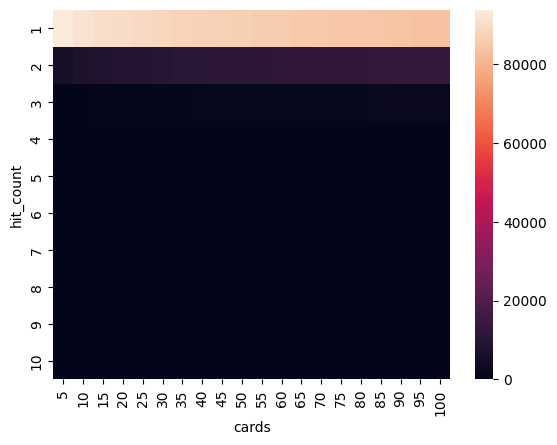

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

piv = df.to_pandas().pivot(index="hit_count", columns="cards", values="cnt").fillna(0)
sns.heatmap(piv)

In [ ]:
%%sql
SELECT * FROM raw_scr LIMIT 500